In [36]:
 # Required packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


In [28]:
"""
df_de = pd.read_csv("DE_out.csv",sep = '\t')

df_es = pd.read_csv("ES_out.csv",sep = '\t')
df_fr = pd.read_csv("FR_out.csv",sep = '\t')
df_it = pd.read_csv("IT_out.csv",sep = '\t')

# Add L1 column
df_de['L1'] = 'de'
df_es['L1'] = 'es'
df_fr['L1'] = 'fr'
df_it['L1'] = 'it'

# Merge (stack) all dataframes
df = pd.concat([df_de, df_es, df_fr, df_it], ignore_index=True)
"""


In [42]:
df = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Data%20Generation/europarl/europarl_all_data.csv")

In [43]:
df = df.drop(columns="sentlength",axis = "columns")
df = df.drop(columns=["afile","alang","akorp","afile",'astatus'],axis = "columns")
df = df.drop(columns=["Unnamed: 0"],axis = "columns")


num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)

df

Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']


,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,attrib,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
0,0.039545,0.008407,0.001713,0.827907,0.130233,0.288372,0.027907,0.0,0.604651,1.720930,...,3.712601,1.654477,0.102911,0.288514,0.096755,0.069001,0.076851,0.047887,0.155290,de
1,0.036732,0.007532,0.002183,0.780908,0.114241,0.394366,0.034429,0.0,0.633803,1.630673,...,3.658930,1.561047,0.131230,0.332131,0.076399,0.056733,0.062148,0.030897,0.139883,de
2,0.055108,0.008050,0.002064,0.794872,0.076923,0.379487,0.051282,0.0,0.471795,1.451282,...,3.522374,1.493397,0.074891,0.374189,0.061194,0.073040,0.051246,0.029586,0.157283,de
3,0.041111,0.009752,0.001824,0.893082,0.088050,0.385744,0.031447,0.0,0.683438,1.735849,...,3.761589,1.590119,0.127679,0.321543,0.073849,0.067222,0.061054,0.039927,0.191326,de
4,0.039280,0.007365,0.001364,0.662252,0.072848,0.218543,0.033113,0.0,0.509934,1.490066,...,3.490749,1.545698,0.082009,0.366746,0.064191,0.083349,0.060328,0.024614,0.120088,de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1685,0.028302,0.007793,0.001641,1.187500,0.125000,0.593750,0.000000,0.0,0.765625,2.484375,...,4.251303,1.817585,0.162630,0.346869,0.073605,0.080444,0.071937,0.044593,0.204297,it
1686,0.037433,0.009958,0.001291,1.050633,0.069620,0.398734,0.018987,0.0,0.670886,2.189873,...,3.992658,1.691587,0.150789,0.346793,0.057961,0.111705,0.040137,0.041821,0.150165,it
1687,0.046539,0.011053,0.002909,0.940000,0.080000,0.560000,0.020000,0.0,0.800000,1.740000,...,3.876865,1.744063,0.079238,0.343654,0.075434,0.099005,0.083434,0.034244,0.144991,it
1688,0.045723,0.010324,0.001844,1.000000,0.109756,0.463415,0.000000,0.0,0.646341,1.780488,...,3.930501,1.661223,0.100132,0.268741,0.089589,0.128712,0.083301,0.062955,0.132424,it


Clustering Accuracy: 0.4990808823529412
Pred   de   fr   it
True               
de    183   81    8
es     63  101  108
fr     80  167   25
it     10   69  193

Classification Report:
               precision    recall  f1-score   support

          de     0.5446    0.6728    0.6020       272
          es     0.0000    0.0000    0.0000       272
          fr     0.3995    0.6140    0.4841       272
          it     0.5778    0.7096    0.6370       272

    accuracy                         0.4991      1088
   macro avg     0.3805    0.4991    0.4307      1088
weighted avg     0.3805    0.4991    0.4307      1088



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


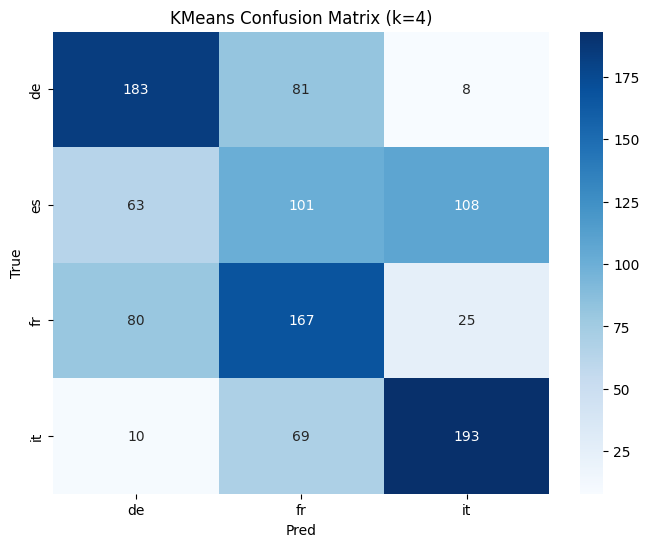

In [44]:

df = (
    df
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)


def run_kmeans_evaluation(df, n_clusters=4, label_col='L1', drop_cols=None, plot=True):

    df = df.dropna().copy()

    # Drop non-feature columns
    if drop_cols is not None:
        df_features = df.drop(drop_cols, axis=1)
    else:
        df_features = df.copy()

    X = df_features.values

    # Fit KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['cluster'] = kmeans.fit_predict(X)

    y_true = df[label_col].values
    y_pred = df['cluster'].values

    # Map clusters to majority labels
    labels = np.empty_like(y_pred, dtype=object)
    for cluster in np.unique(y_pred):
        mask = (y_pred == cluster)
        unique_labels, counts = np.unique(y_true[mask], return_counts=True)
        labels[mask] = unique_labels[np.argmax(counts)]

    # Metrics
    accuracy = accuracy_score(y_true, labels)
    print("Clustering Accuracy:", accuracy)

    confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Pred'])
    print(confusion_matrix)

    print("\nClassification Report:\n", classification_report(y_true, labels, digits=4))

    # Plot
    if plot:
        plt.figure(figsize=(8,6))
        sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
        plt.title(f'KMeans Confusion Matrix (k={n_clusters})')
        plt.show()

    # Clean up
    df = df.drop('cluster', axis=1)

    return df, accuracy, confusion_matrix

df, acc, cm = run_kmeans_evaluation(
    df,
    n_clusters=4,
    label_col='L1',
    drop_cols=[ 'L1']
)

In [45]:
df

,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,attrib,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
93,0.043094,0.008017,0.002095,0.662447,0.061181,0.284810,0.012658,0.0,0.518987,1.550633,...,3.421209,1.498155,0.118115,0.286876,0.088887,0.064911,0.067944,0.025298,0.128558,de
320,0.047052,0.009433,0.001348,0.632153,0.068120,0.365123,0.027248,0.0,0.572207,1.307902,...,3.428033,1.552758,0.064615,0.348009,0.075585,0.077178,0.060838,0.023236,0.127105,de
55,0.039933,0.008009,0.001001,0.990323,0.093548,0.377419,0.035484,0.0,0.612903,1.796774,...,3.666006,1.638769,0.132323,0.307605,0.079835,0.068974,0.058556,0.041503,0.143463,de
30,0.037661,0.010902,0.001982,0.584615,0.084615,0.246154,0.030769,0.0,0.446154,1.115385,...,3.416511,1.531270,0.096319,0.408810,0.079249,0.055788,0.060495,0.009487,0.120623,de
449,0.038876,0.007068,0.003213,0.739837,0.040650,0.345528,0.032520,0.0,0.500000,1.235772,...,3.548635,1.559114,0.076503,0.325158,0.096756,0.076451,0.087875,0.025680,0.165828,de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,0.034853,0.007708,0.000335,1.209877,0.086420,0.358025,0.037037,0.0,0.864198,2.543210,...,3.935940,1.712908,0.124958,0.305228,0.104746,0.077195,0.067812,0.052538,0.131722,it
1555,0.026627,0.011095,0.000740,1.217391,0.028986,0.695652,0.057971,0.0,0.695652,3.144928,...,4.128105,1.725913,0.162302,0.358609,0.063475,0.096894,0.054158,0.077019,0.144065,it
1330,0.052411,0.011006,0.001048,1.129630,0.111111,0.425926,0.000000,0.0,1.018519,1.685185,...,3.665000,1.769516,0.101272,0.368335,0.025603,0.099097,0.014029,0.063588,0.105852,it
1287,0.034467,0.010190,0.001499,1.187817,0.096447,0.543147,0.050761,0.0,0.822335,2.020305,...,3.863615,1.664220,0.126393,0.385276,0.069967,0.080294,0.057742,0.018584,0.119612,it


Accuracy: 0.7614678899082569
              precision    recall  f1-score   support

          de       0.82      0.93      0.87        55
          es       0.63      0.59      0.61        54
          fr       0.82      0.76      0.79        55
          it       0.76      0.76      0.76        54

    accuracy                           0.76       218
   macro avg       0.76      0.76      0.76       218
weighted avg       0.76      0.76      0.76       218



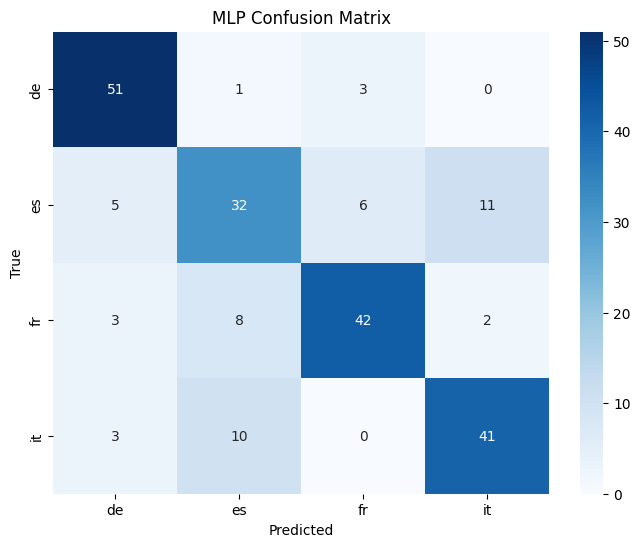

In [53]:

feature_cols = [c for c in df.columns if c != 'L1']

X = df[feature_cols].to_numpy(dtype=np.float64)
y = df['L1'].to_numpy()
# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # converts ['de', 'es', 'fr', 'it'] → [0, 1, 2, 3]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Fit MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True
)

mlp.fit(X_train_s, y_train)

# Predictions
y_pred = mlp.predict(X_test_s)

# Decode labels for reporting (optional)
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)


print("Accuracy:", accuracy_score(y_test_labels, y_pred_labels))
print(classification_report(y_test_labels, y_pred_labels))

# Confusion matrix
labels_order = le.classes_
conf_mat = confusion_matrix(y_test_labels, y_pred_labels, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [33]:
# idea zero shot on text itself if LLM can identify the shining through.